# Modèle 3 — XGBoost (Gradient Boosting)


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, mean_absolute_error,
    mean_squared_error, r2_score
)

RANDOM_STATE = 42
os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

print("Imports OK")

Imports OK


## Chargement des données preprocessées

Mêmes données que les modèles précédents.
On charge les fichiers .npy générés par le preprocessing.

In [30]:
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')

# Classification — données rééquilibrées par undersampling
X_train_under     = np.load('../data/processed/X_train_under.npy')
y_train_clf_under = np.load('../data/processed/y_train_clf_under.npy')

# Labels originaux (pour régression)
y_train_clf = np.load('../data/processed/y_train_clf.npy')
y_test_clf  = np.load('../data/processed/y_test_clf.npy')
y_train_reg = np.load('../data/processed/y_train_reg.npy')
y_test_reg  = np.load('../data/processed/y_test_reg.npy')

feature_names = pd.read_csv('../data/processed/feature_names.csv')['0'].tolist()

print(f"Données chargées")
print(f"   X_train         : {X_train.shape} (original)")
print(f"   X_train_under   : {X_train_under.shape} (rééquilibré 50/50)")
print(f"   X_test          : {X_test.shape}")
print(f"   Churners train_under : {y_train_clf_under.sum()} ({y_train_clf_under.mean()*100:.1f}%)")
print(f"   Churners test        : {y_test_clf.sum()} ({y_test_clf.mean()*100:.1f}%)")


Données chargées
   X_train         : (8000, 51) (original)
   X_train_under   : (1634, 51) (rééquilibré 50/50)
   X_test          : (2000, 51)
   Churners train_under : 817 (50.0%)
   Churners test        : 204 (10.2%)


## Tâche 1 — Classification du Churn


In [ ]:
# TÂCHE 1 — CLASSIFICATION

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,  # Données déjà équilibrées par undersampling
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    verbosity=0
)
X_train_under     = np.load('../data/processed/X_train_under.npy')
y_train_clf_under = np.load('../data/processed/y_train_clf_under.npy')

# Entraînement sur les données rééquilibrées (undersampling)
xgb_clf.fit(X_train_under, y_train_clf_under)

y_pred_clf  = xgb_clf.predict(X_test)
y_proba_clf = xgb_clf.predict_proba(X_test)[:, 1]

print(" Modèle entraîné !")
print(f"\n Résultats — XGBoost (Classification)")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_clf):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_clf):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_clf):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_clf):.4f}")

 Modèle entraîné !

 Résultats — XGBoost (Classification)
   Accuracy  : 0.7125
   Precision : 0.2300
   Recall    : 0.7745
   F1-Score  : 0.3547
   ROC-AUC   : 0.7806


## 🔴 Matrice de Confusion


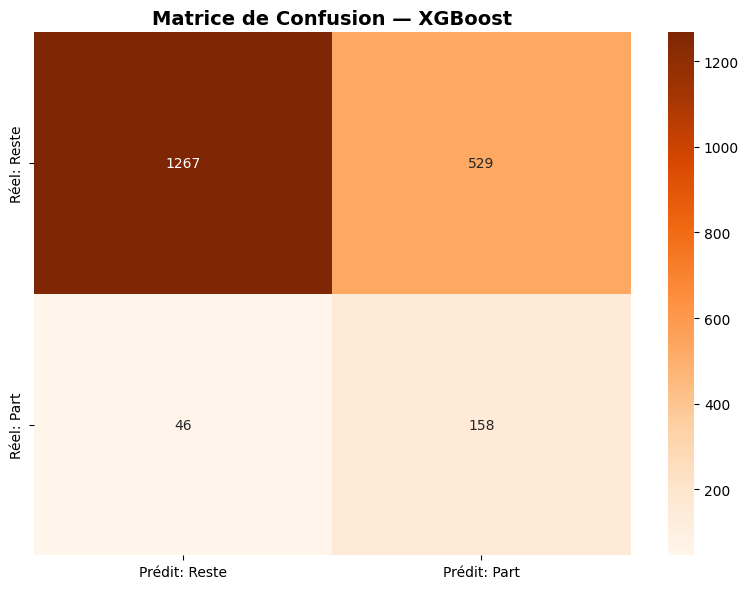


Analyse de la matrice :
   Vrais Négatifs  (TN) : 1267
   Faux Positifs   (FP) : 529
   Faux Négatifs   (FN) : 46 → churners manqués 
   Vrais Positifs  (TP) : 158 → churners détectés 

 Comparaison modèles précédents :
   LR  → FN=71,  TP=133
   RF  → FN=111, TP=93
   XGB → FN=46, TP=158


In [32]:
# MATRICE DE CONFUSION

cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Prédit: Reste', 'Prédit: Part'],
            yticklabels=['Réel: Reste', 'Réel: Part'])
plt.title('Matrice de Confusion — XGBoost',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/xgb_confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nAnalyse de la matrice :")
print(f"   Vrais Négatifs  (TN) : {tn}")
print(f"   Faux Positifs   (FP) : {fp}")
print(f"   Faux Négatifs   (FN) : {fn} → churners manqués ")
print(f"   Vrais Positifs  (TP) : {tp} → churners détectés ")
print(f"\n Comparaison modèles précédents :")
print(f"   LR  → FN=71,  TP=133")
print(f"   RF  → FN=111, TP=93")
print(f"   XGB → FN={fn}, TP={tp}")

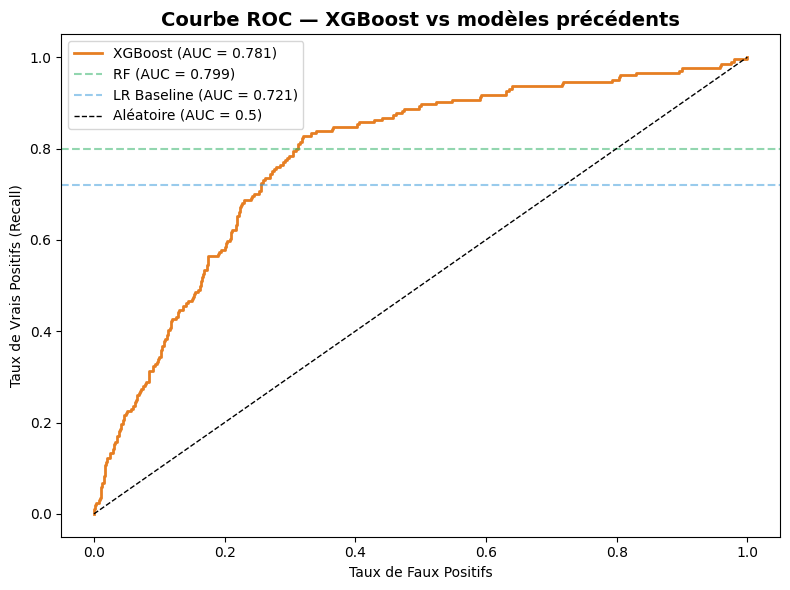

In [33]:
# COURBE ROC — Comparaison tous les modèles

fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf)
auc = roc_auc_score(y_test_clf, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e67e22', linewidth=2,
         label=f'XGBoost (AUC = {auc:.3f})')
plt.axhline(y=0.7993, color='#27ae60', linestyle='--',
            alpha=0.5, label='RF (AUC = 0.799)')
plt.axhline(y=0.7212, color='#3498db', linestyle='--',
            alpha=0.5, label='LR Baseline (AUC = 0.721)')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1,
         label='Aléatoire (AUC = 0.5)')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.title('Courbe ROC — XGBoost vs modèles précédents',
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/xgb_roc_curve.png', dpi=150)
plt.show()

## 🔍 Feature Importance XGBoost


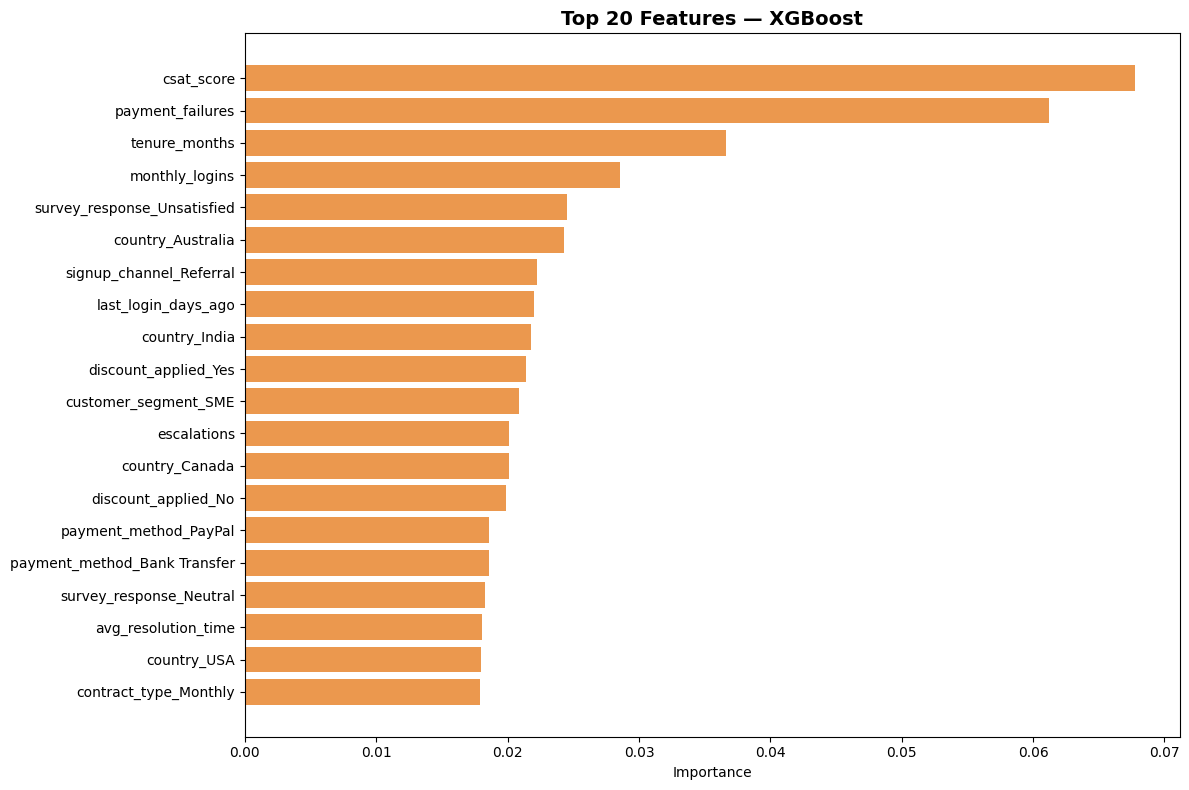


 Top 10 features les plus importantes :
   1. csat_score                          : 0.0678
   2. payment_failures                    : 0.0612
   3. tenure_months                       : 0.0366
   4. monthly_logins                      : 0.0285
   5. survey_response_Unsatisfied         : 0.0245
   6. country_Australia                   : 0.0243
   7. signup_channel_Referral             : 0.0222
   8. last_login_days_ago                 : 0.0220
   9. country_India                       : 0.0218
   10. discount_applied_Yes                : 0.0214


In [34]:
# FEATURE IMPORTANCE

importances = xgb_clf.feature_importances_
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 8))
plt.barh(range(20),
         importances[indices][::-1],
         color='#e67e22', alpha=0.8)
plt.yticks(range(20),
           [feature_names[i] for i in indices][::-1],
           fontsize=10)
plt.xlabel('Importance')
plt.title('Top 20 Features — XGBoost',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/xgb_feature_importance.png', dpi=150)
plt.show()

print("\n Top 10 features les plus importantes :")
for i in range(10):
    print(f"   {i+1}. {feature_names[indices[i]]:35} : {importances[indices[i]]:.4f}")

## Tâche 2 — Régression du Revenu à Risque


In [35]:
# TÂCHE 2 — RÉGRESSION

xgb_reg = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    verbosity=0
)

xgb_reg.fit(X_train, y_train_reg)

y_pred_reg = xgb_reg.predict(X_test)
y_pred_reg = np.maximum(y_pred_reg, 0)

mae  = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2   = r2_score(y_test_reg, y_pred_reg)

print("Modèle de régression entraîné !")
print(f"\n Résultats — XGBoost Regression")
print(f"   MAE  : {mae:.2f} €")
print(f"   RMSE : {rmse:.2f} €")
print(f"   R²   : {r2:.4f}")
print(f"\n Comparaison modèles précédents :")
print(f"   Ridge → MAE=156.11€, R²=0.0533")
print(f"   RF    → MAE=145.39€, R²=0.0612")
print(f"   XGB   → MAE={mae:.2f}€,  R²={r2:.4f}")

Modèle de régression entraîné !

 Résultats — XGBoost Regression
   MAE  : 158.61 €
   RMSE : 386.03 €
   R²   : -0.0024

 Comparaison modèles précédents :
   Ridge → MAE=156.11€, R²=0.0533
   RF    → MAE=145.39€, R²=0.0612
   XGB   → MAE=158.61€,  R²=-0.0024


In [36]:
# SAUVEGARDE

joblib.dump(xgb_clf, '../models/xgb_classification.pkl')
joblib.dump(xgb_reg, '../models/xgb_regression.pkl')

results_clf = {
    'model'    : 'XGBoost',
    'accuracy' : accuracy_score(y_test_clf, y_pred_clf),
    'precision': precision_score(y_test_clf, y_pred_clf),
    'recall'   : recall_score(y_test_clf, y_pred_clf),
    'f1'       : f1_score(y_test_clf, y_pred_clf),
    'roc_auc'  : roc_auc_score(y_test_clf, y_proba_clf)
}

results_reg = {
    'model': 'XGBoost Regression',
    'mae' : mae,
    'rmse': rmse,
    'r2'  : r2
}

pd.DataFrame([results_clf]).to_csv('../results/xgb_clf_results.csv', index=False)
pd.DataFrame([results_reg]).to_csv('../results/xgb_reg_results.csv', index=False)

print("Modèles sauvegardés dans ../models/")
print("Résultats sauvegardés dans ../results/")
print(f"\n Résumé Classification :")
for k, v in results_clf.items():
    if k != 'model':
        print(f"   {k:10} : {v:.4f}")

Modèles sauvegardés dans ../models/
Résultats sauvegardés dans ../results/

 Résumé Classification :
   accuracy   : 0.7125
   precision  : 0.2300
   recall     : 0.7745
   f1         : 0.3547
   roc_auc    : 0.7806


## Synthèse — XGBoost
